In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_ef_AC_stark_vals=[np.float64(0.6225948637445211), np.float64(0.6334656814566403), np.float64(0.6230882765524478), np.float64(0.5994626490319437), np.float64(0.5765887988951279), np.float64(0.5554667261420007), np.float64(0.5310964307725617), np.float64(0.5044779127868111), np.float64(0.4786111721847489), np.float64(0.451496208966375), np.float64(0.42313302313168943), np.float64(0.39252161468069235), np.float64(0.36066198361338364), np.float64(0.3265541299297633), np.float64(0.2931980536298313), np.float64(0.25559375471358753), np.float64(0.2197412331810324), np.float64(0.19164048903216546), np.float64(0.14429152226698688), np.float64(0.10769433288549693)]

list_AC_stark_vals=[np.float64(-0.06854670085959402), np.float64(-0.08153707558259009), np.float64(-0.09579972281290855), np.float64(-0.1112346425505495), np.float64(-0.12794183479551288), np.float64(-0.1459212995477987), np.float64(-0.165373036807407), np.float64(-0.18579704657433777), np.float64(-0.20819332884859085), np.float64(-0.23176188363016656), np.float64(-0.25670271091906466), np.float64(-0.28311581071528513), np.float64(-0.3106011830188282), np.float64(-0.3400588278296935), np.float64(-0.37078874514788146), np.float64(-0.4024909349733919), np.float64(-0.43426539730622454), np.float64(-0.4636121321463798), np.float64(-0.5065311394938574), np.float64(-0.5382224193486578)]
list_AC_stark_vals=[np.float64(-0.06854670085959402), np.float64(-0.08163707558259009), np.float64(-0.09679972281290855), np.float64(-0.11283464255054951), np.float64(-0.1303418347955129), np.float64(-0.1502212995477987), np.float64(-0.17277303680740702), np.float64(-0.19449704657433778), np.float64(-0.21819332884859086), np.float64(-0.24566188363016658), np.float64(-0.2670027109190647), np.float64(-0.29221581071528513), np.float64(-0.3198011830188282), np.float64(-0.3490588278296935), np.float64(-0.37578874514788146), np.float64(-0.4090909349733919), np.float64(-0.43466539730622455), np.float64(-0.4645121321463798), np.float64(-0.5076311394938574), np.float64(-0.5387224193486577)]


## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def find_params(f_d,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        if A < 8:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=5,drag=True)
        elif A < 15:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=1,drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_d,f_ef/3+delta,A,evolution,dim,f_rabi,t_ramp=10,U_f=0,drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

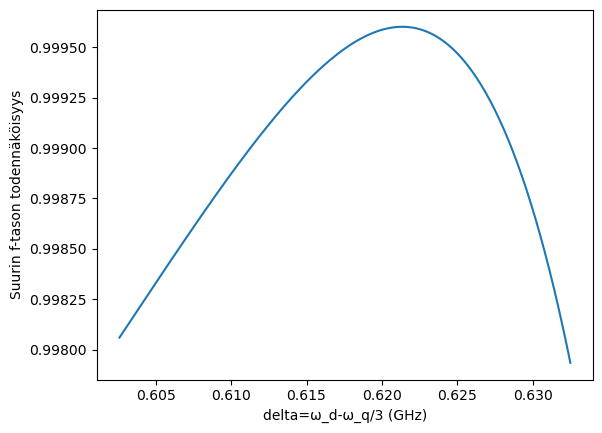

Amplitudi (GHz): 5.862378319586982
AC-stark siirtymä (GHz): 0.6213948637445211
E-tason suurin todennäköisyys: 0.9996865372074824
Pulssin pituus (ns): 254.84630806891238
Rabi-taajuus (fourier):  0.002185167692923797


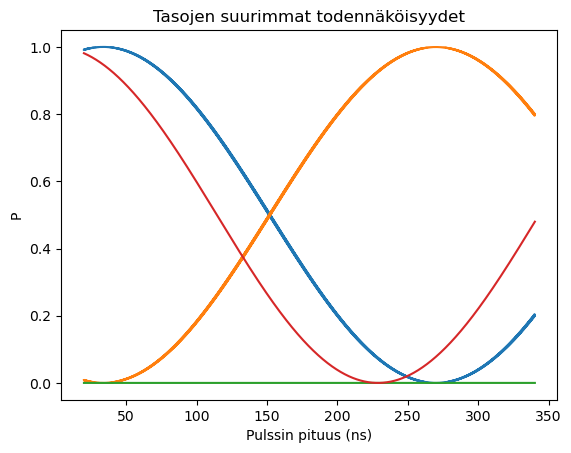

---------------------------------------------


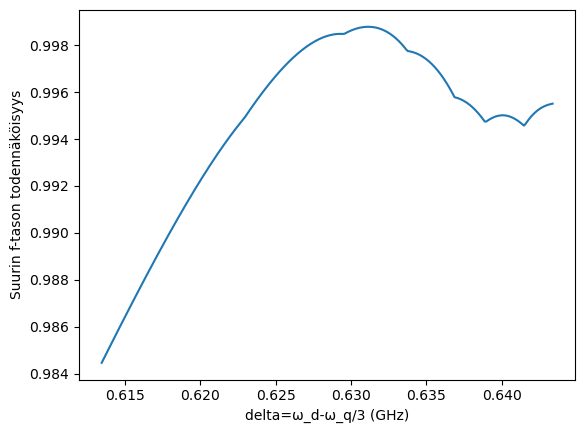

Amplitudi (GHz): 6.425810560828751
AC-stark siirtymä (GHz): 0.6311656814566403
E-tason suurin todennäköisyys: 0.998892574863496
Pulssin pituus (ns): 202.9423975259218
Rabi-taajuus (fourier):  0.0026510445867922974


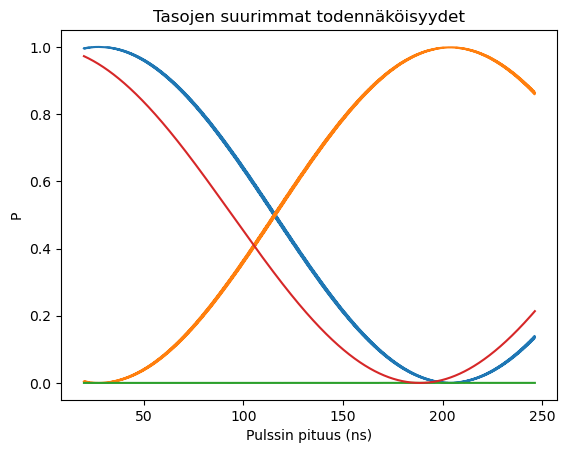

---------------------------------------------


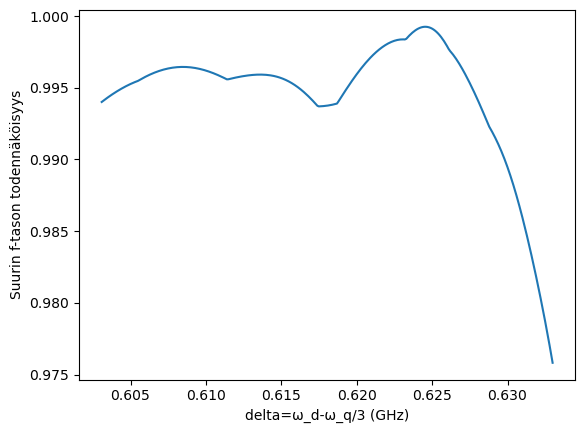

Amplitudi (GHz): 6.98924280207052
AC-stark siirtymä (GHz): 0.6245882765524478
E-tason suurin todennäköisyys: 0.9995559467218733
Pulssin pituus (ns): 158.38954917858456
Rabi-taajuus (fourier):  0.003522932636883705


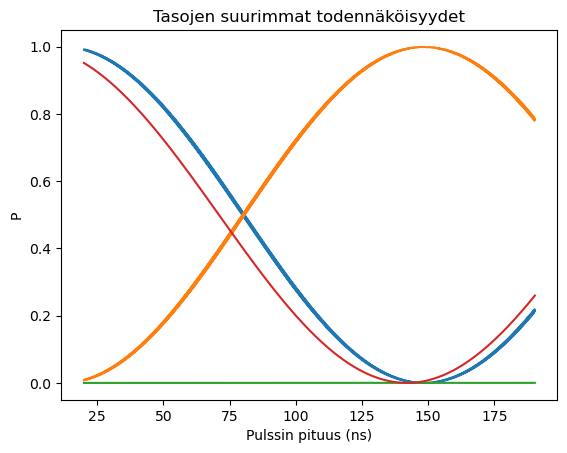

---------------------------------------------


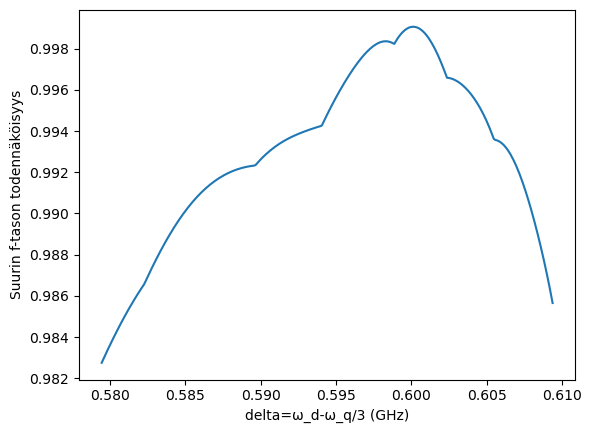

Amplitudi (GHz): 7.55267504331229
AC-stark siirtymä (GHz): 0.6001626490319437
E-tason suurin todennäköisyys: 0.9986351572662698
Pulssin pituus (ns): 117.43271466507906
Rabi-taajuus (fourier):  0.004518045409218768


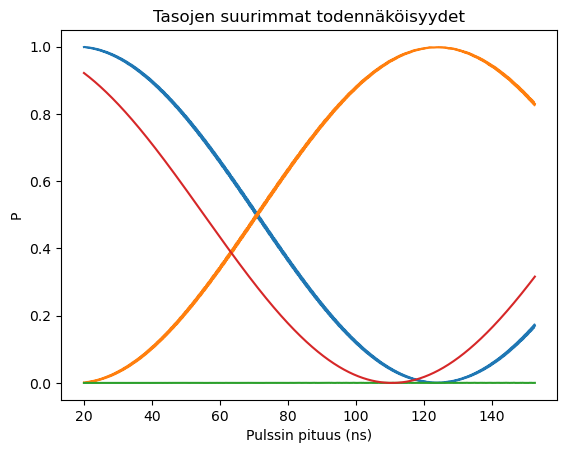

---------------------------------------------


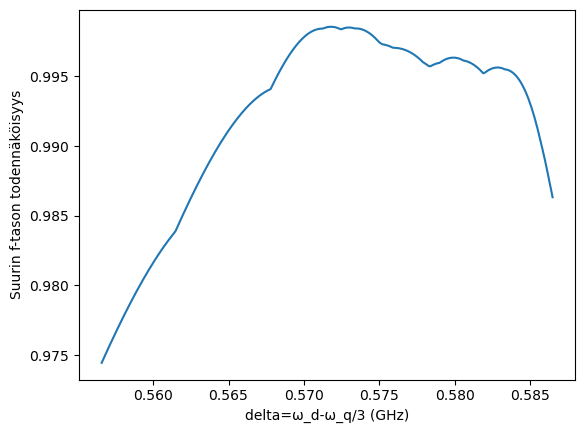

Amplitudi (GHz): 8.11610728455406
AC-stark siirtymä (GHz): 0.5717887988951279
E-tason suurin todennäköisyys: 0.9957243806433218
Pulssin pituus (ns): 97.35823845319746
Rabi-taajuus (fourier):  0.005666021152155837


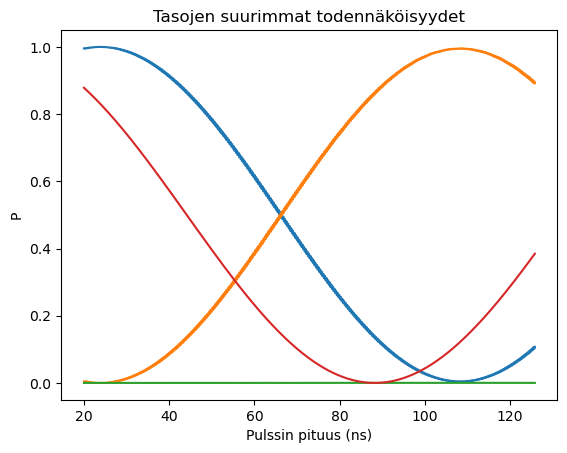

---------------------------------------------


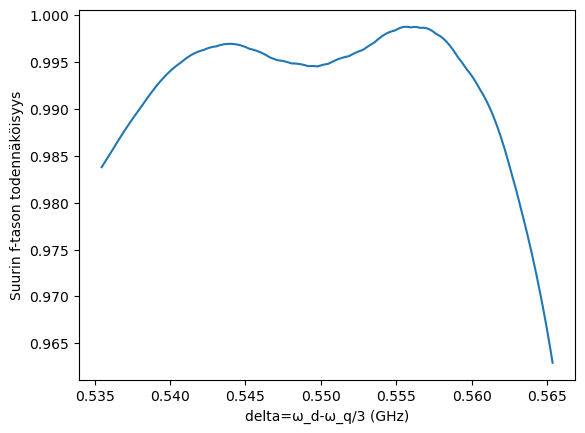

Amplitudi (GHz): 8.679539525795828
AC-stark siirtymä (GHz): 0.5556667261420006
E-tason suurin todennäköisyys: 0.9978212534784936
Pulssin pituus (ns): 80.98002402161434
Rabi-taajuus (fourier):  0.006995982297221164


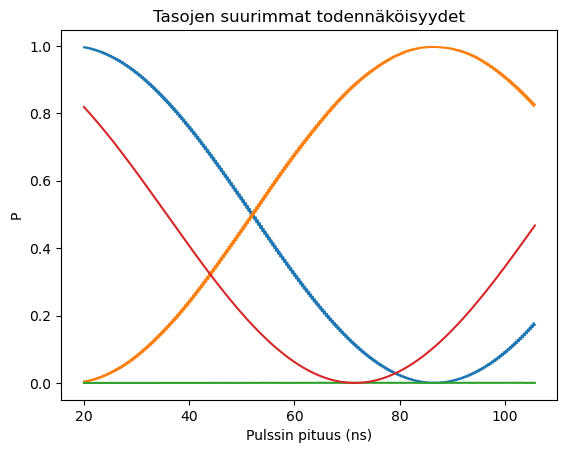

---------------------------------------------


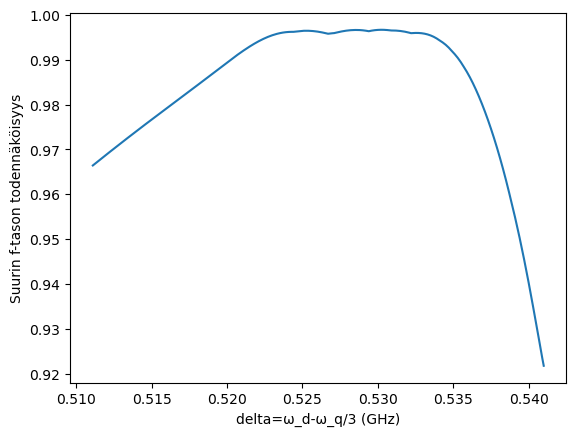

Amplitudi (GHz): 9.242971767037599
AC-stark siirtymä (GHz): 0.5301964307725617
E-tason suurin todennäköisyys: 0.9939002928363873
Pulssin pituus (ns): 84.91964292330155
Rabi-taajuus (fourier):  0.008537824491362013


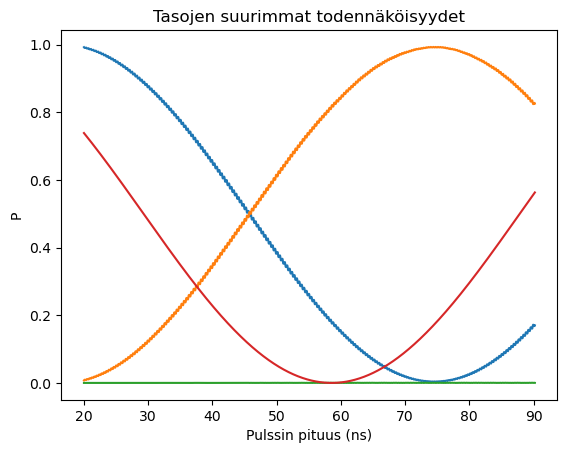

---------------------------------------------


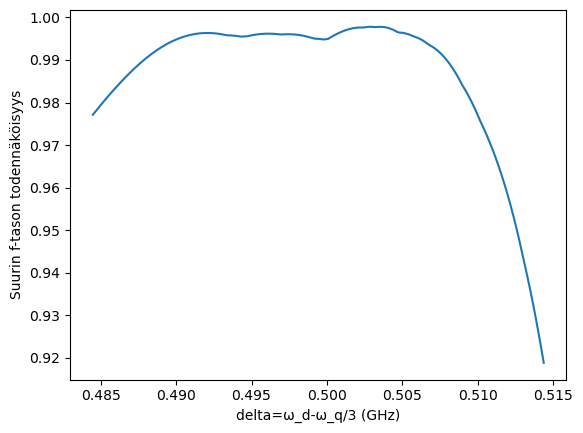

Amplitudi (GHz): 9.806404008279367
AC-stark siirtymä (GHz): 0.502877912786811
E-tason suurin todennäköisyys: 0.9974314120706408
Pulssin pituus (ns): 69.95242656403289
Rabi-taajuus (fourier):  0.010320977488613766


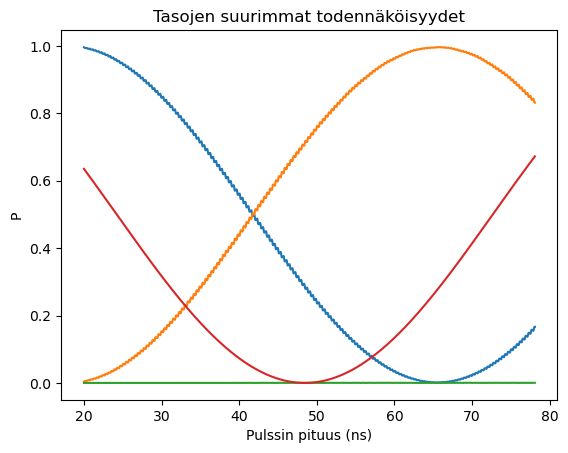

---------------------------------------------


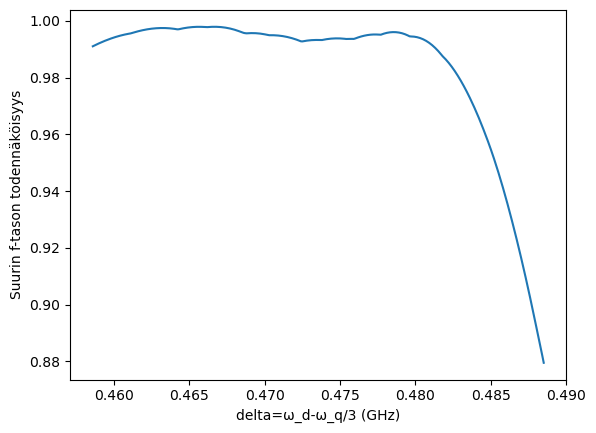

Amplitudi (GHz): 10.369836249521137
AC-stark siirtymä (GHz): 0.4667111721847489
E-tason suurin todennäköisyys: 0.9990069678460579
Pulssin pituus (ns): 61.74618193575948
Rabi-taajuus (fourier):  0.012374631381125331


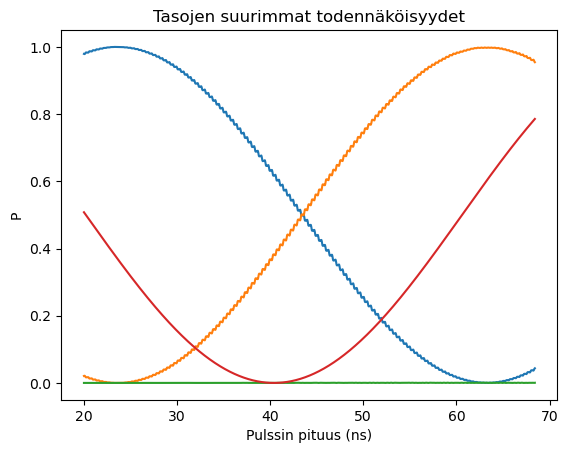

---------------------------------------------


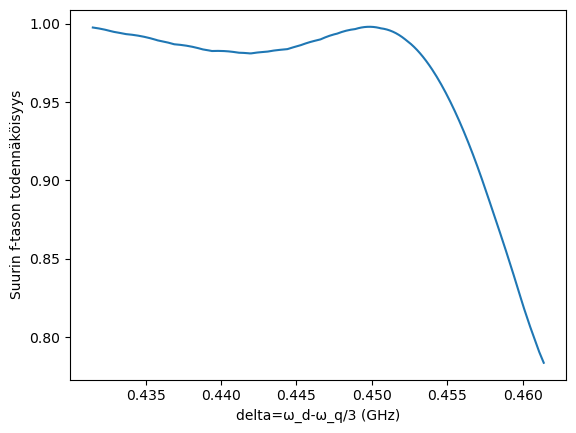

Amplitudi (GHz): 10.933268490762906
AC-stark siirtymä (GHz): 0.449796208966375
E-tason suurin todennäköisyys: 0.998723530661432
Pulssin pituus (ns): 48.93884312776031
Rabi-taajuus (fourier):  0.01472788856645419


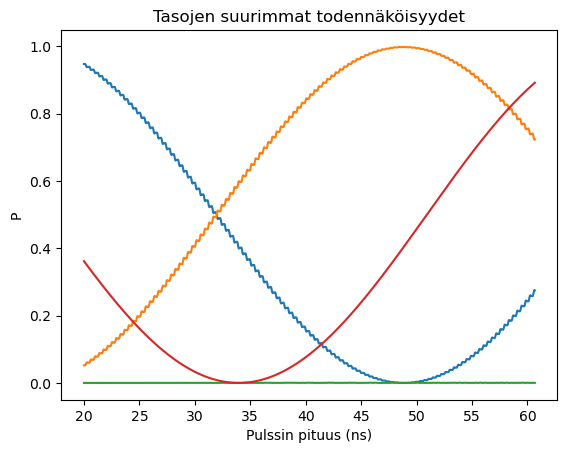

---------------------------------------------


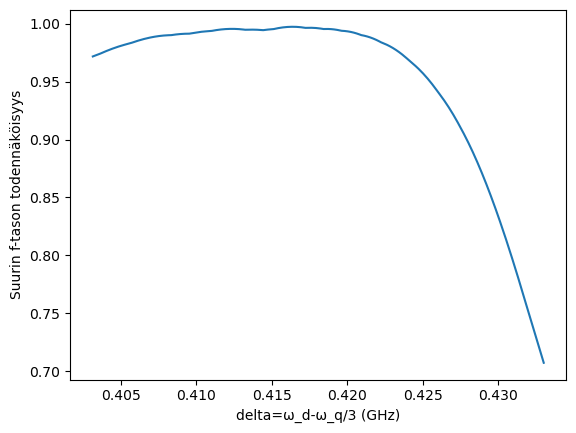

Amplitudi (GHz): 11.496700732004676
AC-stark siirtymä (GHz): 0.41643302313168945
E-tason suurin todennäköisyys: 0.996184784336906
Pulssin pituus (ns): 46.723320106281975
Rabi-taajuus (fourier):  0.017410667995365423


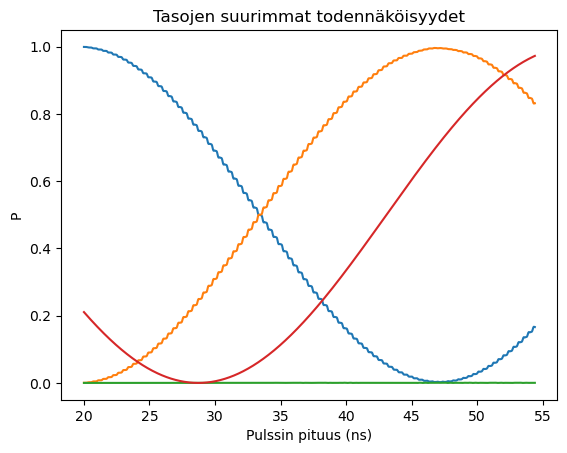

---------------------------------------------


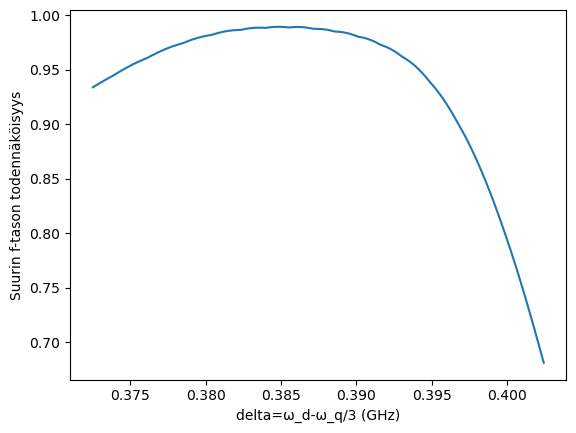

Amplitudi (GHz): 12.060132973246446
AC-stark siirtymä (GHz): 0.38482161468069237
E-tason suurin todennäköisyys: 0.9871632299789639
Pulssin pituus (ns): 42.97609846929667
Rabi-taajuus (fourier):  0.02045490408075484


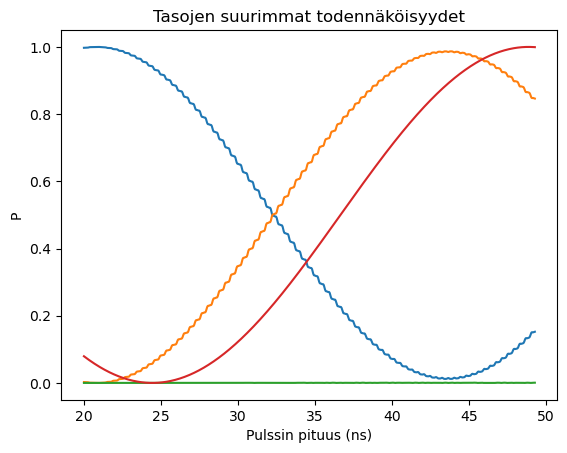

---------------------------------------------


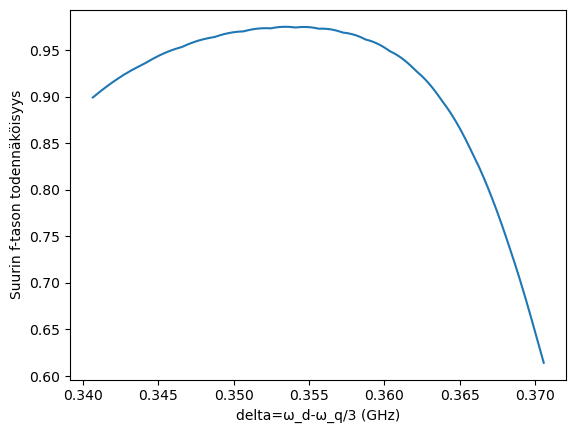

Amplitudi (GHz): 12.623565214488215
AC-stark siirtymä (GHz): 0.35346198361338366
E-tason suurin todennäköisyys: 0.9784534067232207
Pulssin pituus (ns): 39.979799467872624
Rabi-taajuus (fourier):  0.02786540389997831


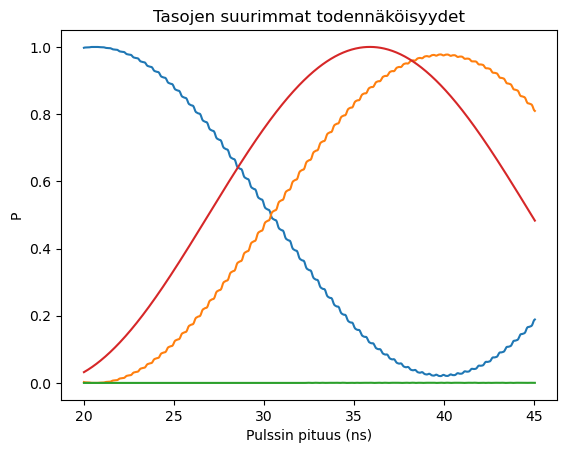

---------------------------------------------


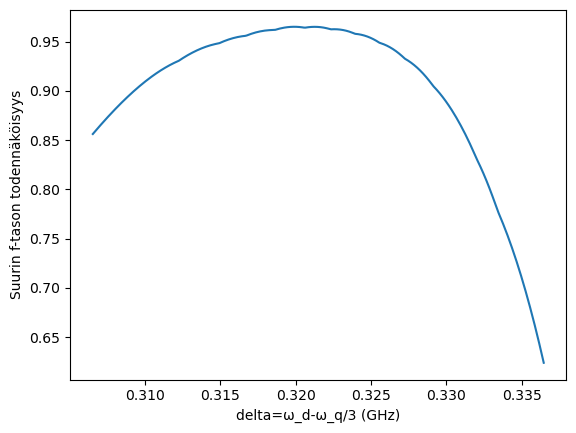

Amplitudi (GHz): 13.186997455729985
AC-stark siirtymä (GHz): 0.3199541299297633
E-tason suurin todennäköisyys: 0.9754296176373891
Pulssin pituus (ns): 37.737909629344784
Rabi-taajuus (fourier):  0.03235866325611125


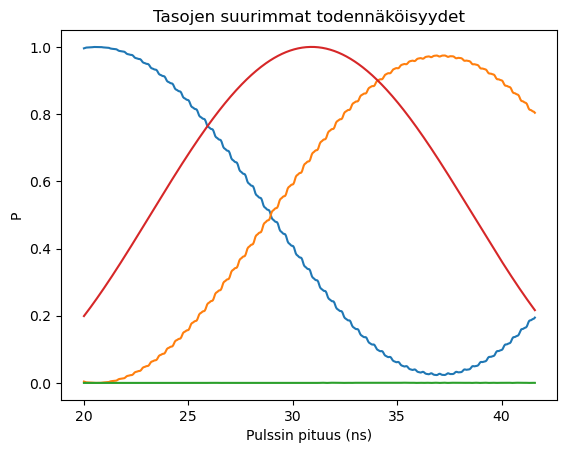

---------------------------------------------


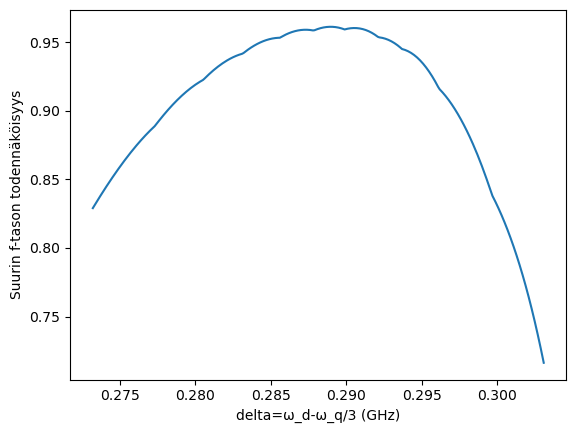

Amplitudi (GHz): 13.750429696971754
AC-stark siirtymä (GHz): 0.28899805362983133
E-tason suurin todennäköisyys: 0.9599117870651102
Pulssin pituus (ns): 33.92753710729165
Rabi-taajuus (fourier):  0.03736813570446625


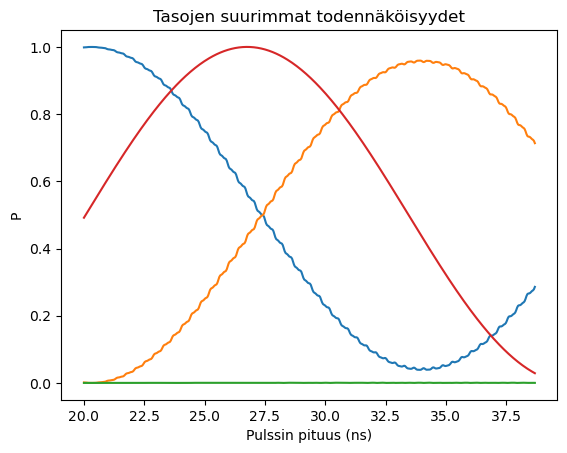

---------------------------------------------


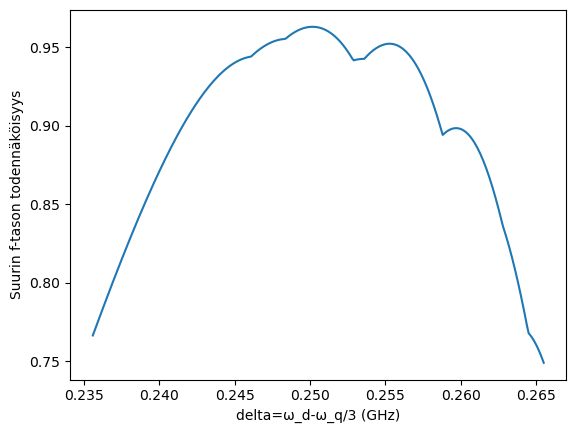

Amplitudi (GHz): 14.313861938213524
AC-stark siirtymä (GHz): 0.2501937547135875
E-tason suurin todennäköisyys: 0.9642397303942102
Pulssin pituus (ns): 33.20795147507767
Rabi-taajuus (fourier):  0.042934115783494244


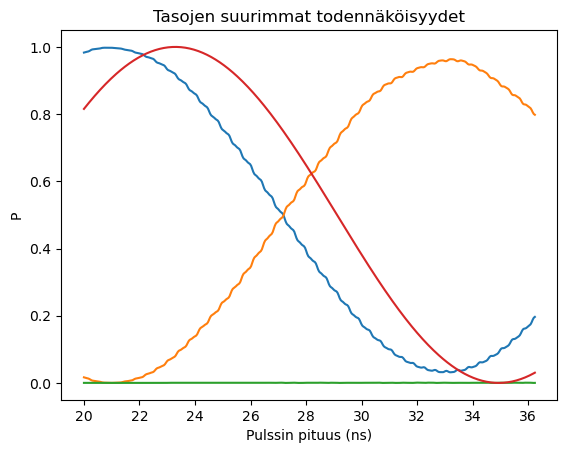

---------------------------------------------


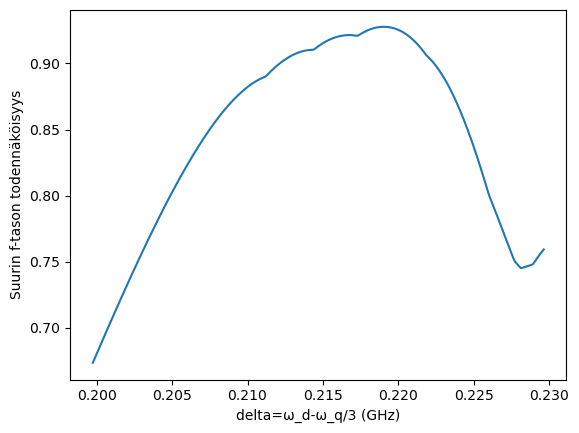

Amplitudi (GHz): 14.877294179455292
AC-stark siirtymä (GHz): 0.21904123318103239
E-tason suurin todennäköisyys: 0.9270850524744458
Pulssin pituus (ns): 30.91164320217393
Rabi-taajuus (fourier):  0.04910460405951863


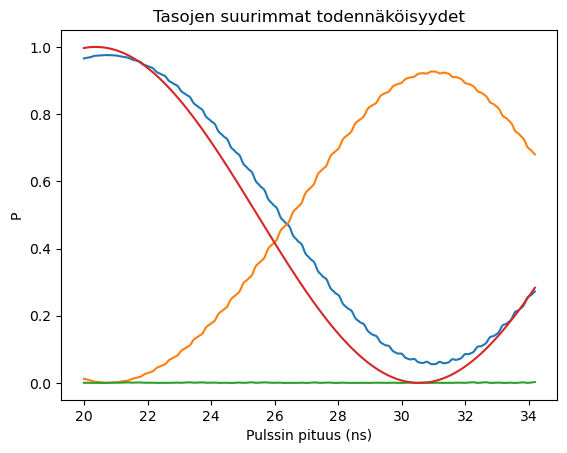

---------------------------------------------


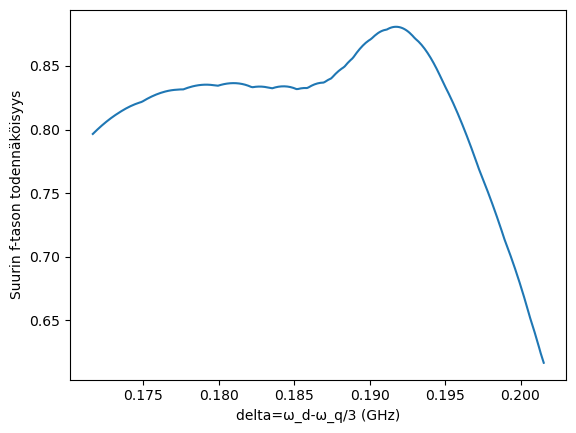

Amplitudi (GHz): 15.440726420697063
AC-stark siirtymä (GHz): 0.19174048903216545
E-tason suurin todennäköisyys: 0.8853948519411537
Pulssin pituus (ns): 26.72777520923311
Rabi-taajuus (fourier):  0.055889945626423534


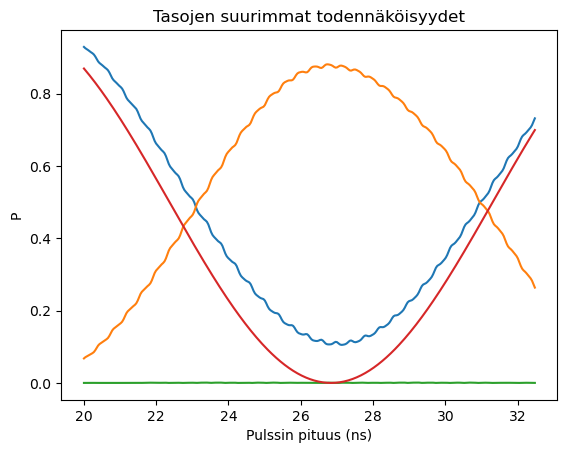

---------------------------------------------


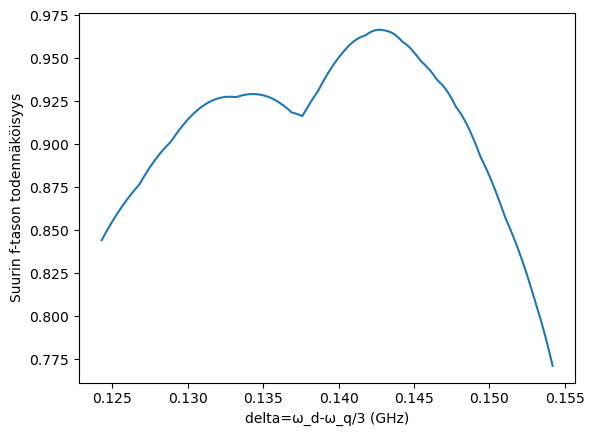

Amplitudi (GHz): 16.00415866193883
AC-stark siirtymä (GHz): 0.1426915222669869
E-tason suurin todennäköisyys: 0.9666621128590104
Pulssin pituus (ns): 27.393306547700167
Rabi-taajuus (fourier):  0.06332224882722634


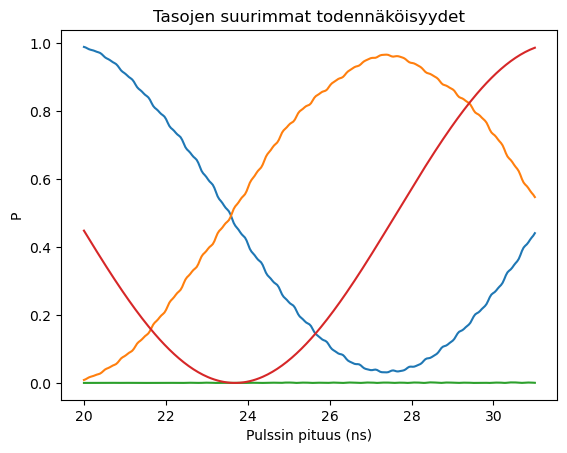

---------------------------------------------


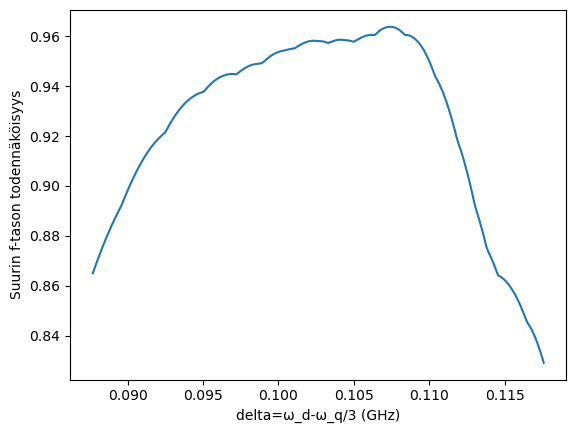

Amplitudi (GHz): 16.5675909031806
AC-stark siirtymä (GHz): 0.10739433288549693
E-tason suurin todennäköisyys: 0.9642380359204172
Pulssin pituus (ns): 26.198321175345235
Rabi-taajuus (fourier):  0.07146556837190854


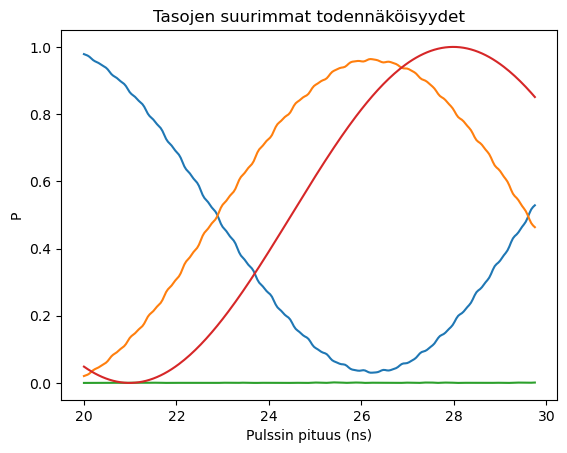

---------------------------------------------


In [7]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.65
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_d_opt = qubit.frequency/3+list_AC_stark_vals[i] #Optimaalinen ajotaajuus

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=list_ef_AC_stark_vals[i] #Arvaus AC-stark siirtymälle
    params=find_params(f_d_opt, A, evolution_eigenbasis,f_rabi*10,AC_stark,[-200,100],10000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    m=10

    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef/3+deltas[-1],A,evolution_eigenbasis,dim,(10*f_rabi)/m,t_ramp=10,U_f=0,drag=True)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319586982), np.float64(6.425810560828751), np.float64(6.98924280207052), np.float64(7.55267504331229), np.float64(8.11610728455406), np.float64(8.679539525795828), np.float64(9.242971767037599), np.float64(9.806404008279367), np.float64(10.369836249521137), np.float64(10.933268490762906), np.float64(11.496700732004676), np.float64(12.060132973246446), np.float64(12.623565214488215), np.float64(13.186997455729985), np.float64(13.750429696971754), np.float64(14.313861938213524), np.float64(14.877294179455292), np.float64(15.440726420697063), np.float64(16.00415866193883), np.float64(16.5675909031806)]


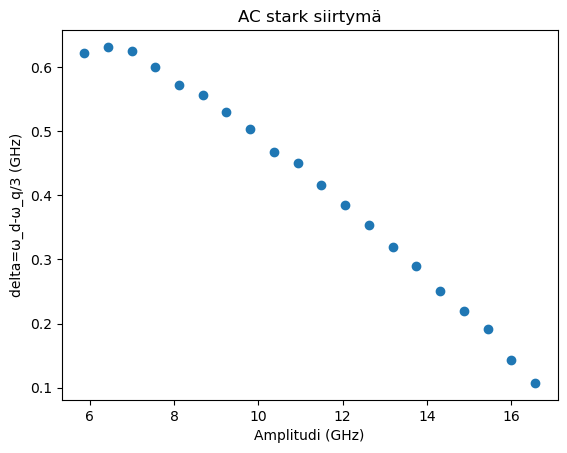

[np.float64(0.6213948637445211), np.float64(0.6311656814566403), np.float64(0.6245882765524478), np.float64(0.6001626490319437), np.float64(0.5717887988951279), np.float64(0.5556667261420006), np.float64(0.5301964307725617), np.float64(0.502877912786811), np.float64(0.4667111721847489), np.float64(0.449796208966375), np.float64(0.41643302313168945), np.float64(0.38482161468069237), np.float64(0.35346198361338366), np.float64(0.3199541299297633), np.float64(0.28899805362983133), np.float64(0.2501937547135875), np.float64(0.21904123318103239), np.float64(0.19174048903216545), np.float64(0.1426915222669869), np.float64(0.10739433288549693)]


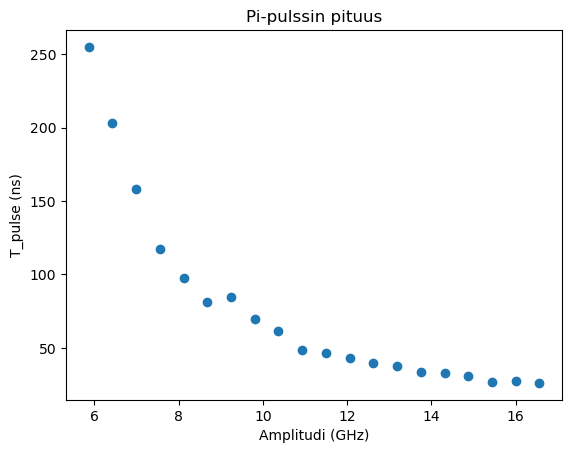

[np.float64(254.84630806891238), np.float64(202.9423975259218), np.float64(158.38954917858456), np.float64(117.43271466507906), np.float64(97.35823845319746), np.float64(80.98002402161434), np.float64(84.91964292330155), np.float64(69.95242656403289), np.float64(61.74618193575948), np.float64(48.93884312776031), np.float64(46.723320106281975), np.float64(42.97609846929667), np.float64(39.979799467872624), np.float64(37.737909629344784), np.float64(33.92753710729165), np.float64(33.20795147507767), np.float64(30.91164320217393), np.float64(26.72777520923311), np.float64(27.393306547700167), np.float64(26.198321175345235)]


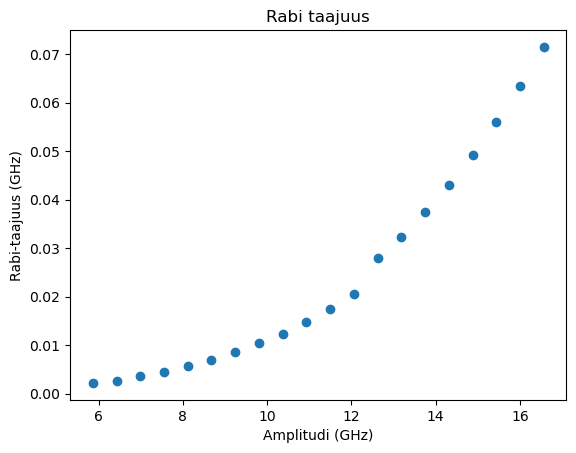

[np.float64(0.002185167692923797), np.float64(0.0026510445867922974), np.float64(0.003522932636883705), np.float64(0.004518045409218768), np.float64(0.005666021152155837), np.float64(0.006995982297221164), np.float64(0.008537824491362013), np.float64(0.010320977488613766), np.float64(0.012374631381125331), np.float64(0.01472788856645419), np.float64(0.017410667995365423), np.float64(0.02045490408075484), np.float64(0.02786540389997831), np.float64(0.03235866325611125), np.float64(0.03736813570446625), np.float64(0.042934115783494244), np.float64(0.04910460405951863), np.float64(0.055889945626423534), np.float64(0.06332224882722634), np.float64(0.07146556837190854)]


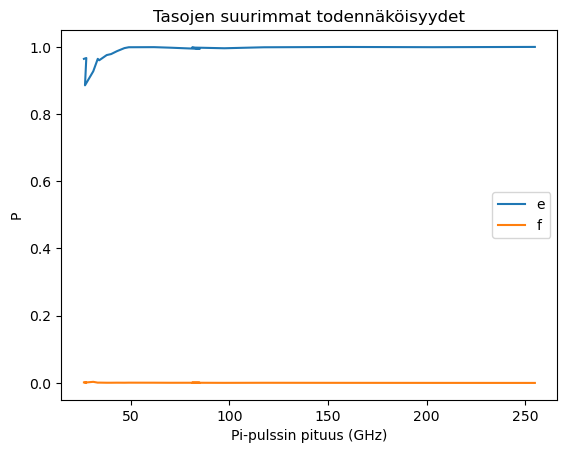

[np.float64(0.9996865372074824), np.float64(0.998892574863496), np.float64(0.9995559467218733), np.float64(0.9986351572662698), np.float64(0.9957243806433218), np.float64(0.9978212534784936), np.float64(0.9939002928363873), np.float64(0.9974314120706408), np.float64(0.9990069678460579), np.float64(0.998723530661432), np.float64(0.996184784336906), np.float64(0.9871632299789639), np.float64(0.9784534067232207), np.float64(0.9754296176373891), np.float64(0.9599117870651102), np.float64(0.9642397303942102), np.float64(0.9270850524744458), np.float64(0.8853948519411537), np.float64(0.9666621128590104), np.float64(0.9642380359204172)]
[np.float64(8.360090252718217e-05), np.float64(0.00018802613138565387), np.float64(0.0003225074900806359), np.float64(0.0005108233786641392), np.float64(0.00031022000913221316), np.float64(0.0005997763248834866), np.float64(0.0005980311654674882), np.float64(0.0005218179819350687), np.float64(0.0007208603710040727), np.float64(0.0008427738389634716), np.float6

In [8]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)